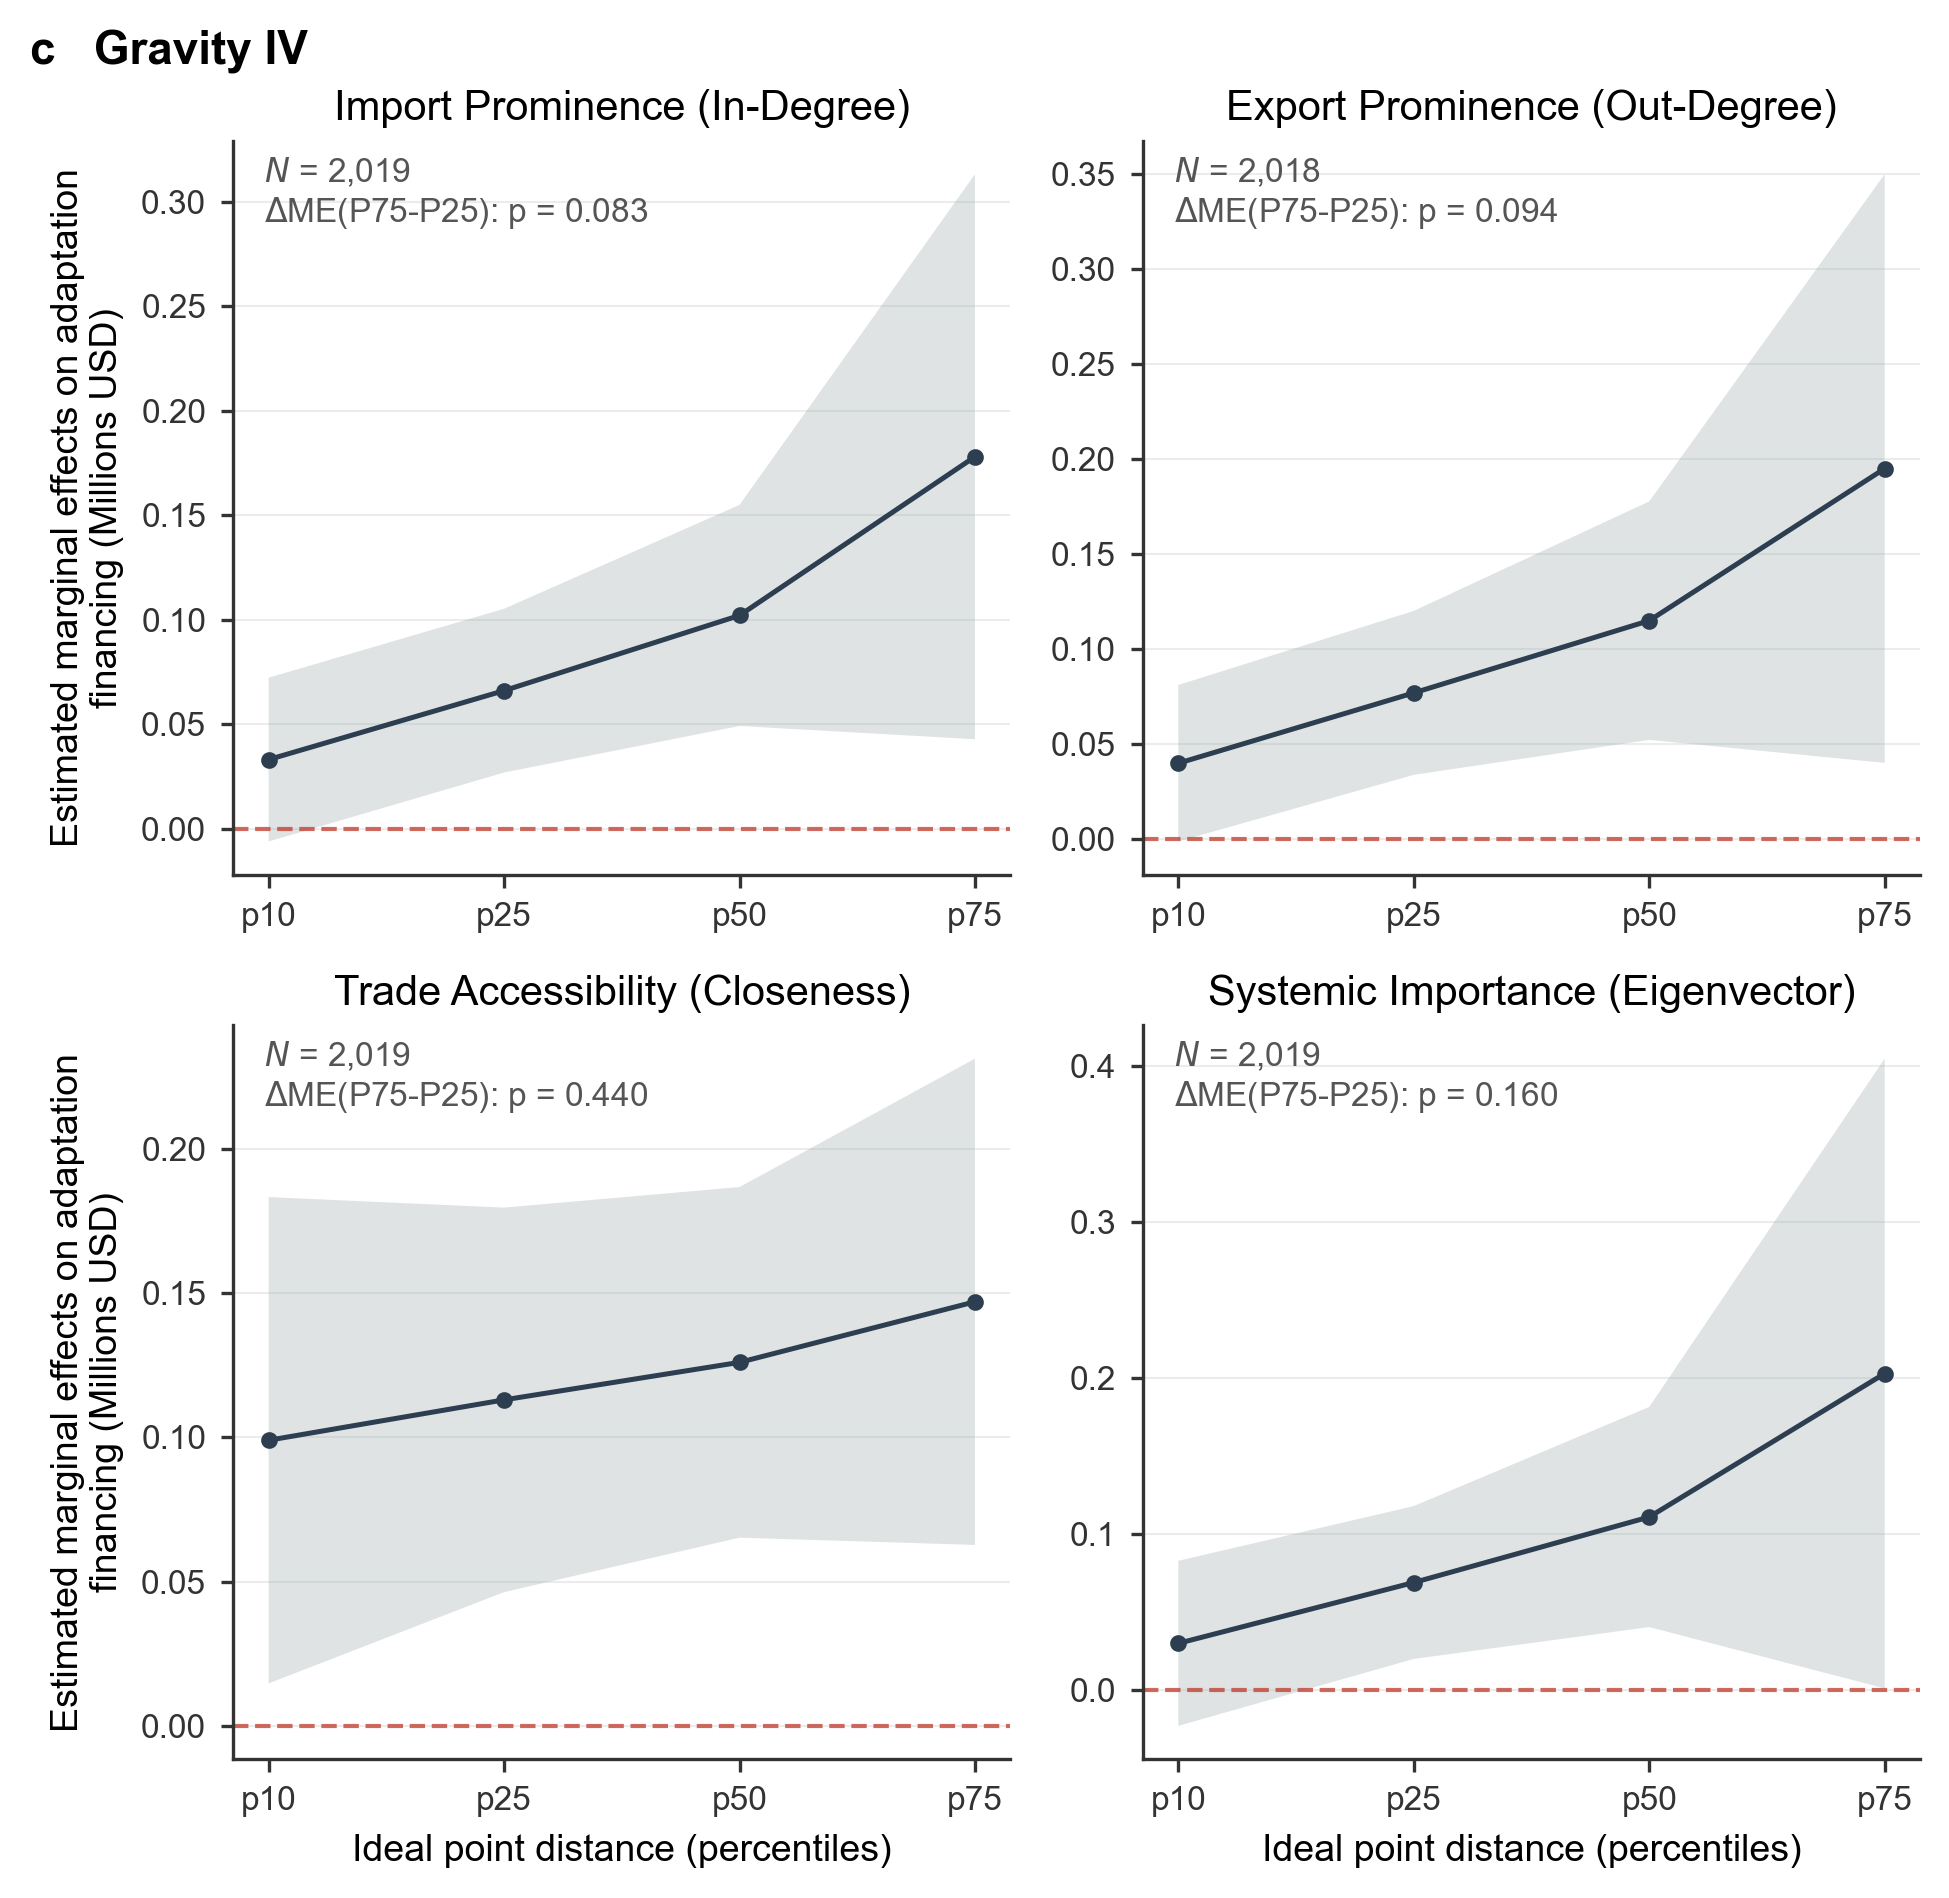

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, re, math

plt.rcParams.update({
    'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':9,'axes.titlesize':10,'axes.labelsize':9,
    'xtick.labelsize':8,'ytick.labelsize':8,'axes.linewidth':0.8
})

centralities = ['in_degree','out_degree','closeness','eigenvector']
titles = {
    'in_degree':'Import Prominence (In-Degree)',
    'out_degree':'Export Prominence (Out-Degree)',
    'closeness':'Trade Accessibility (Closeness)',
    'eigenvector':'Systemic Importance (Eigenvector)'
}
cols = dict(zip(centralities, [1,2,3,4]))
labels = ['P10','P25','P50','P75']
x = np.arange(len(labels))

margins_csv = "../Moderation_idealpoint_Table2_Main_Regression_CF.csv"
mediff_csv  = "../Moderation_idealpoint_Table3_Marginal_Effects_Differences_CF.csv"

def clean(x):
    if pd.isna(x): return ""
    return re.sub(r'^="|"$','',str(x).strip()).replace('="','').replace('"','').strip()

def num(x):
    x = clean(x).replace('*','').replace('(','').replace(')','').replace(',','').replace('=','').strip()
    return np.nan if x in ["","nan","NaN","."] else float(x)

def fp(coef,se):
    if pd.isna(coef) or pd.isna(se) or se == 0: return "p = NA"
    p = math.erfc(abs(coef/se)/math.sqrt(2))
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

def read_csv(path):
    df = pd.read_csv(path, header=None, skiprows=1, dtype=str).map(clean)
    df.columns = range(df.shape[1])
    return df

diff_keys = {
    "p25_p10":"ME(P25) - ME(P10)",
    "p50_p10":"ME(P50) - ME(P10)",
    "p75_p25":"ME(P75) - ME(P25)",
    "p90_p10":"ME(P90) - ME(P10)",
    "p75_p50":"ME(P75) - ME(P50)",
    "p90_p50":"ME(P90) - ME(P50)"
}

target_diff = "p75_p25"
df_diff = read_csv(mediff_csv)
r = df_diff.index[df_diff.iloc[:,0].str.contains(diff_keys[target_diff], case=False, na=False, regex=False)]
if len(r) == 0: raise ValueError(f"Cannot find row: {diff_keys[target_diff]}")
r = r[0]
pvals = {v: fp(num(df_diff.iloc[r, cols[v]]), num(df_diff.iloc[r+1, cols[v]])) for v in centralities}

df = read_csv(margins_csv)

fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.2), dpi=300)
axes = axes.flatten()

for i, v in enumerate(centralities):
    ax, c = axes[i], cols[v]
    m, se = [], []

    for lab in labels:
        idx = df.index[df.iloc[:,0].str.contains(f"ME at {lab}", case=False, na=False, regex=False)]
        if len(idx) == 0: raise ValueError(f"Cannot find row: ME at {lab}")
        idx = idx[0]
        m.append(num(df.iloc[idx, c]))
        se.append(num(df.iloc[idx+1, c]))

    m, se = np.array(m), np.array(se)
    lb, ub = m - 1.96 * se, m + 1.96 * se

    obs_idx = df.index[df.iloc[:,0].str.contains("Observation", case=False, na=False, regex=False)]
    obs = "NA" if len(obs_idx) == 0 or pd.isna(num(df.iloc[obs_idx[0], c])) else f"{int(num(df.iloc[obs_idx[0], c])):,}"

    ax.fill_between(x, lb, ub, color='#95A5A6', alpha=0.30, edgecolor='none')
    ax.plot(x, m, marker='o', linestyle='-', color='#2C3E50', linewidth=1.2, markersize=3, markeredgewidth=1.0)
    ax.axhline(0, color='#C0392B', linestyle='--', linewidth=1, alpha=0.75)

    ax.text(
        0.04, 0.98,
        f"$\\mathit{{N}}$ = {obs}\n$\\Delta$ME(P75-P25): {pvals.get(v,'p = NA')}",
        transform=ax.transAxes, fontsize=8, color='#555555',
        va='top', ha='left'
    )

    ax.set_title(titles[v], pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels([l.lower() for l in labels])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(colors='#333333', direction='out', length=3, width=0.8)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='-', color='#E0E0E0', alpha=0.6, linewidth=0.5)

    if i % 2 == 0:
        ax.set_ylabel('Estimated marginal effects on adaptation\nfinancing (Millions USD)')
    if i >= 2:
        ax.set_xlabel('Ideal point distance (percentiles)')

plt.tight_layout()

fig.text(0.01, 1.01, 'c   Gravity IV', fontsize=11, fontweight='bold', va='top', ha='left')

plt.savefig('Final/Fig.6_marginal_effects_idealpoint_GravityIV.pdf', bbox_inches='tight', transparent=True)
plt.savefig('Final/Fig.6_marginal_effects_idealpoint_GravityIV.png', dpi=1200, bbox_inches='tight')
plt.show()

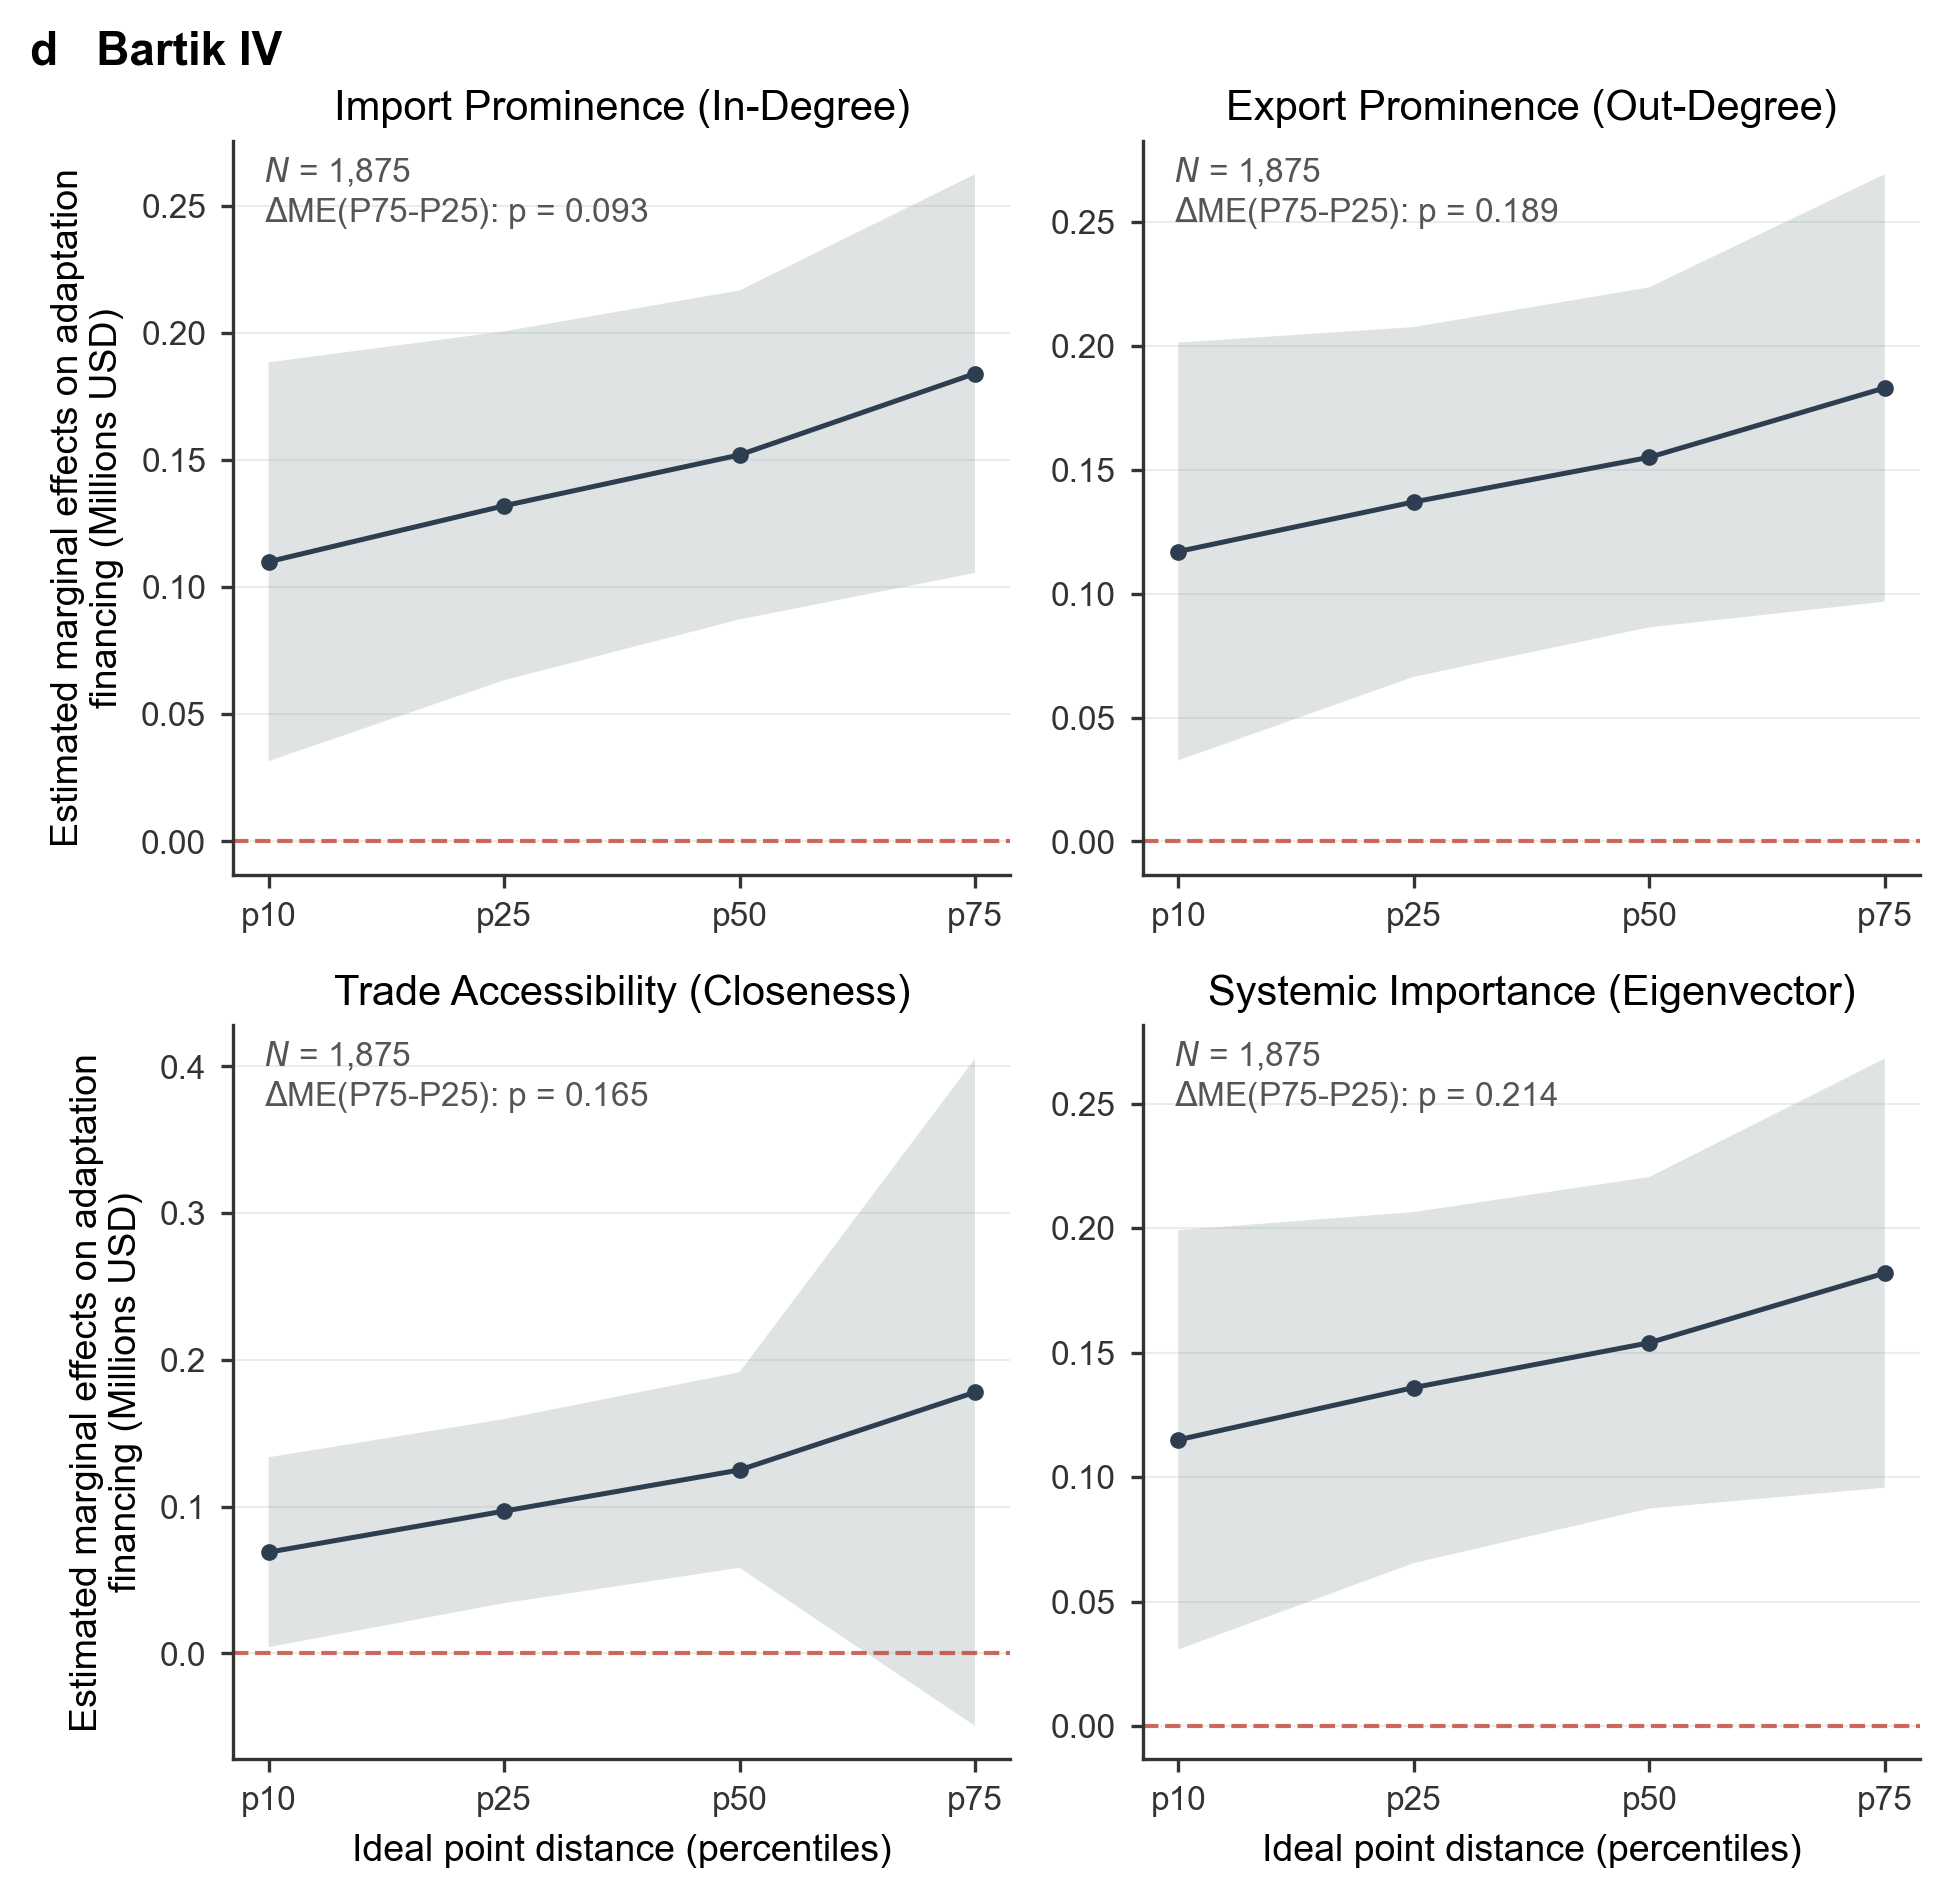

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, re, math

plt.rcParams.update({
    'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':9,'axes.titlesize':10,'axes.labelsize':9,
    'xtick.labelsize':8,'ytick.labelsize':8,'axes.linewidth':0.8
})

centralities = ['in_degree','out_degree','closeness','eigenvector']
titles = {
    'in_degree':'Import Prominence (In-Degree)',
    'out_degree':'Export Prominence (Out-Degree)',
    'closeness':'Trade Accessibility (Closeness)',
    'eigenvector':'Systemic Importance (Eigenvector)'
}
cols = dict(zip(centralities, [1,2,3,4]))
labels = ['P10','P25','P50','P75']
x = np.arange(len(labels))

margins_csv = "../Moderation_idealpoint_Table2_Main_Regression_CF_Bartik.csv"
mediff_csv  = "../Moderation_idealpoint_Table3_Marginal_Effects_Differences_CF_Bartik.csv"

def clean(x):
    if pd.isna(x): return ""
    return re.sub(r'^="|"$','',str(x).strip()).replace('="','').replace('"','').strip()

def num(x):
    x = clean(x).replace('*','').replace('(','').replace(')','').replace(',','').replace('=','').strip()
    return np.nan if x in ["","nan","NaN","."] else float(x)

def fp(coef,se):
    if pd.isna(coef) or pd.isna(se) or se == 0: return "p = NA"
    p = math.erfc(abs(coef/se)/math.sqrt(2))
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

def read_csv(path):
    df = pd.read_csv(path, header=None, skiprows=1, dtype=str).map(clean)
    df.columns = range(df.shape[1])
    return df

diff_keys = {
    "p25_p10":"ME(P25) - ME(P10)",
    "p50_p10":"ME(P50) - ME(P10)",
    "p75_p25":"ME(P75) - ME(P25)",
    "p90_p10":"ME(P90) - ME(P10)",
    "p75_p50":"ME(P75) - ME(P50)",
    "p90_p50":"ME(P90) - ME(P50)"
}

target_diff = "p75_p25"
df_diff = read_csv(mediff_csv)
r = df_diff.index[df_diff.iloc[:,0].str.contains(diff_keys[target_diff], case=False, na=False, regex=False)]
if len(r) == 0: raise ValueError(f"Cannot find row: {diff_keys[target_diff]}")
r = r[0]
pvals = {v: fp(num(df_diff.iloc[r, cols[v]]), num(df_diff.iloc[r+1, cols[v]])) for v in centralities}

df = read_csv(margins_csv)

fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.2), dpi=300)
axes = axes.flatten()

for i, v in enumerate(centralities):
    ax, c = axes[i], cols[v]
    m, se = [], []

    for lab in labels:
        idx = df.index[df.iloc[:,0].str.contains(f"ME at {lab}", case=False, na=False, regex=False)]
        if len(idx) == 0: raise ValueError(f"Cannot find row: ME at {lab}")
        idx = idx[0]
        m.append(num(df.iloc[idx, c]))
        se.append(num(df.iloc[idx+1, c]))

    m, se = np.array(m), np.array(se)
    lb, ub = m - 1.96 * se, m + 1.96 * se

    obs_idx = df.index[df.iloc[:,0].str.contains("Observation", case=False, na=False, regex=False)]
    obs = "NA" if len(obs_idx) == 0 or pd.isna(num(df.iloc[obs_idx[0], c])) else f"{int(num(df.iloc[obs_idx[0], c])):,}"

    ax.fill_between(x, lb, ub, color='#95A5A6', alpha=0.30, edgecolor='none')
    ax.plot(x, m, marker='o', linestyle='-', color='#2C3E50', linewidth=1.2, markersize=3, markeredgewidth=1.0)
    ax.axhline(0, color='#C0392B', linestyle='--', linewidth=1, alpha=0.75)

    ax.text(
        0.04, 0.98,
        f"$\\mathit{{N}}$ = {obs}\n$\\Delta$ME(P75-P25): {pvals.get(v,'p = NA')}",
        transform=ax.transAxes, fontsize=8, color='#555555',
        va='top', ha='left'
    )

    ax.set_title(titles[v], pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels([l.lower() for l in labels])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(colors='#333333', direction='out', length=3, width=0.8)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='-', color='#E0E0E0', alpha=0.6, linewidth=0.5)

    if i % 2 == 0:
        ax.set_ylabel('Estimated marginal effects on adaptation\nfinancing (Millions USD)')
    if i >= 2:
        ax.set_xlabel('Ideal point distance (percentiles)')

plt.tight_layout()

fig.text(0.01, 1.01, 'd   Bartik IV', fontsize=11, fontweight='bold', va='top', ha='left')

plt.savefig('Final/Fig.6_marginal_effects_idealpoint_BartikIV.pdf', bbox_inches='tight', transparent=True)
plt.savefig('Final/Fig.6_marginal_effects_idealpoint_BartikIV.png', dpi=1200, bbox_inches='tight')
plt.show()